In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scienceplots
import uncertainties as unc
from uncertainties import unumpy as unp
import os
import utils as uts

from main_data_processor import Data
# plt.rcParams['text.usetex'] = False
plt.style.use('science')

In [2]:
equillibrium_constans_path = 'source_data/MacromoleculeEquilibria_Crowding'
complexation_data_path = 'source_data/IonCrowderComplexation/raw_data'




all_data =  Data(equillibrium_constans_path, complexation_data_path)

complexation_data = all_data.EquillbriumConstantsObj
equillibrium_constants = all_data.SodiumCrowderComplexationObj

# Sodium crowder complexation

In [3]:
# diffusion coefficient of the Na+ in ultra-pure water
equillibrium_constants.D_Na0

1425.622636

In [4]:
df = equillibrium_constants.analyzed_data

df

,wt_%,D_Na_[um2/s],D_Na_err_[um2/s],D_crowder_[um2/s],D_crowder_err_[um2/s],crowder,D_Na_uf_[um2/s],D_crowder_uf_[um2/s],MW_[g/mol],No_mono,...,density,mass concentration [g/cm3],concentration [M],monomers concentration [M],ksi,D_Na_[um2/s] corr,n Beta [1/M],chi2,redchi2,R^2
0,1.0,1365.0760,37.30372,30.83452,0.055466,PEG35000,(1.37+/-0.04)e+03,30.83+/-0.06,35000.0,794.143,...,0.998744,0.009987,0.000285,0.226613,13.490967,1416.671547,143+/-9,9.525206,1.190651,0.921228
1,1.5,1404.5150,45.17060,26.34168,0.040308,PEG35000,(1.40+/-0.05)e+03,26.34+/-0.04,35000.0,794.143,...,0.999616,0.014994,0.000428,0.340216,9.946959,1412.380653,143+/-9,9.525206,1.190651,0.921228
2,3.0,1237.3990,35.69728,18.37717,0.025882,PEG35000,(1.24+/-0.04)e+03,18.377+/-0.026,35000.0,794.143,...,1.002232,0.030067,0.000859,0.682214,5.902915,1399.778853,143+/-9,9.525206,1.190651,0.921228
3,4.5,1289.8420,62.48437,13.03956,0.061334,PEG35000,(1.29+/-0.06)e+03,13.04+/-0.06,35000.0,794.143,...,1.004848,0.045218,0.001292,1.025991,4.346593,1387.436659,143+/-9,9.525206,1.190651,0.921228
4,6.0,1126.2400,58.74440,10.01745,0.025307,PEG35000,(1.13+/-0.06)e+03,10.017+/-0.025,35000.0,794.143,...,1.007465,0.060448,0.001727,1.371550,3.496214,1375.275703,143+/-9,9.525206,1.190651,0.921228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,7.5,1059.3110,56.60522,146.77290,0.459099,PEG1500,(1.06+/-0.06)e+03,146.8+/-0.5,1500.0,33.643,...,1.010081,0.075756,0.050504,1.699107,2.760586,1359.115805,5.9+/-0.6,4.816534,0.688076,0.953227
85,10.0,1031.9890,160.91470,132.50240,0.334128,PEG1500,(1.03+/-0.16)e+03,132.50+/-0.33,1500.0,33.643,...,1.014441,0.101444,0.067629,2.275256,2.217656,1338.084111,5.9+/-0.6,4.816534,0.688076,0.953227
86,12.5,920.6009,104.00470,113.96290,0.233071,PEG1500,(9.2+/-1.0)e+02,113.96+/-0.23,1500.0,33.643,...,1.018801,0.127350,0.084900,2.856294,1.869884,1317.375825,5.9+/-0.6,4.816534,0.688076,0.953227
87,15.0,831.2803,58.79731,104.98180,0.135397,PEG1500,(8.3+/-0.6)e+02,104.98+/-0.14,1500.0,33.643,...,1.023162,0.153474,0.102316,3.442222,1.625690,1296.953657,5.9+/-0.6,4.816534,0.688076,0.953227


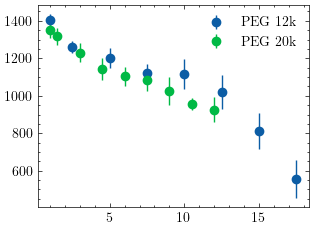

In [5]:
peg_12k = df[df['crowder'] == 'PEG12000']
peg_20k = df[df['crowder'] == 'PEG20000']


plt.errorbar(peg_12k['wt_%'] , peg_12k['D_Na_[um2/s]'], yerr=peg_12k['D_Na_err_[um2/s]'], fmt='o', label='PEG 12k')
plt.errorbar(peg_20k['wt_%'] , peg_20k['D_Na_[um2/s]'], yerr=peg_20k['D_Na_err_[um2/s]'], fmt='o', label='PEG 20k')
plt.legend()

### Nanosiscosity effects

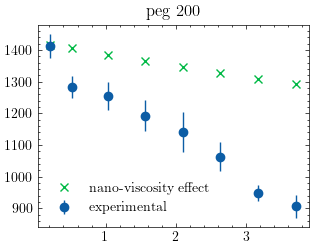

In [6]:
peg200 = df[df['crowder'] == 'PEG200']


D_measured, D_measured_err = uts.get_float_uncertainty(peg200['D_Na_uf_[um2/s]'])

D_viscosity = peg200['D_Na_[um2/s] corr']


plt.errorbar( peg200['monomers concentration [M]'] , D_measured, yerr=D_measured_err, fmt='o', label='experimental')
plt.plot( peg200['monomers concentration [M]'] , D_viscosity, 'x',  label='nano-viscosity effect')
plt.title('peg 200')
plt.legend()

# Fits of the NMR results 

# nBeta as a function of monomer number

In [14]:
peg200

,wt_%,D_Na_[um2/s],D_Na_err_[um2/s],D_crowder_[um2/s],D_crowder_err_[um2/s],crowder,D_Na_uf_[um2/s],D_crowder_uf_[um2/s],MW_[g/mol],No_mono,Rg_[nm],Rg_err_[nm],Rh_[nm],Rh_err_[nm],V_Rg_[nm3],V_Rg_err_[nm3],c*_[g/cm3],density,mass concentration [g/cm3],concentration [M],monomers concentration [M],ksi,D_Na_[um2/s] corr,n Beta [1/M],chi2,redchi2,R^2
32,1.0,1412.3260,38.60817,586.6107,2.625764,PEG200,(1.41+/-0.04)e+03,586.6+/-2.6,200.0,4.131,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,0.998744,0.009987,0.049937,0.206291,12.088670,1417.044932,0.80+/-0.05,4.534651,0.647807,0.960598
33,2.5,1284.2680,34.60799,563.1332,2.004906,PEG200,1284+/-35,563.1+/-2.0,200.0,4.131,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.001360,0.025034,0.125170,0.517077,6.068361,1404.844680,0.80+/-0.05,4.534651,0.647807,0.960598
34,5.0,1255.0480,43.33636,526.7910,2.182739,PEG200,(1.26+/-0.04)e+03,526.8+/-2.2,200.0,4.131,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.005721,0.050286,0.251430,1.038658,3.596530,1385.107831,0.80+/-0.05,4.534651,0.647807,0.960598
35,7.5,1191.7850,49.04247,494.5730,1.811948,PEG200,(1.19+/-0.05)e+03,494.6+/-1.8,200.0,4.131,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.010081,0.075756,0.378780,1.564741,2.644881,1365.812914,0.80+/-0.05,4.534651,0.647807,0.960598
36,10.0,1142.1510,63.22156,462.2113,2.106704,PEG200,(1.14+/-0.06)e+03,462.2+/-2.1,200.0,4.131,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.014441,0.101444,0.507220,2.095328,2.124707,1346.836996,0.80+/-0.05,4.534651,0.647807,0.960598
37,12.5,1063.2300,45.44351,427.1637,2.412526,PEG200,(1.06+/-0.05)e+03,427.2+/-2.4,200.0,4.131,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.018801,0.127350,0.636751,2.630417,1.791511,1328.122868,0.80+/-0.05,4.534651,0.647807,0.960598
38,15.0,948.4644,24.12609,409.2443,2.766944,PEG200,948+/-24,409.2+/-2.8,200.0,4.131,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.023162,0.153474,0.767371,3.170010,1.557552,1309.637639,0.80+/-0.05,4.534651,0.647807,0.960598
39,17.5,905.7463,35.35792,373.3122,1.742018,PEG200,906+/-35,373.3+/-1.7,200.0,4.131,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.027522,0.179816,0.899082,3.714106,1.383080,1291.360207,0.80+/-0.05,4.534651,0.647807,0.960598


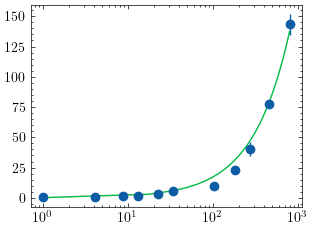

In [7]:
x = df['No_mono'].unique()
y, y_err = uts.get_float_uncertainty(df['n Beta [1/M]'].unique())

a = np.dot(x, y) / np.dot(x, x)

x_int = np.linspace(min(x), max(x))

plt.errorbar(x, y, y_err, fmt='o', label='experimental')
plt.plot(x_int, a * x_int)
plt.xscale('log')

### Checking Ficcols Dextrans

### to be implemented

# Equillibrium constans

# Taylor Series expansion of the theoretical model

In [22]:
a

1.8597491448118586

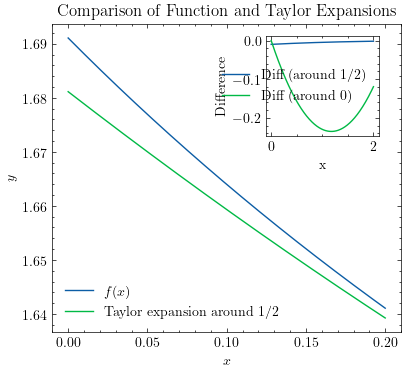

In [89]:
# Define the range for x
x = np.linspace(0, 2, 500)  # Ensure the domain of the function is valid

a = 0.0754 / 0.1754 * 4 + 0.0246 / 0.1754 

Bn = 0.1

# Define the functions
y1 = np.sqrt(1 /(Bn * x + 1) + a)
# Taylor expansion around x = 1/2
sqrt_term = np.sqrt(2 / 3)
y2 =(4 * a + 2) / (3 * np.sqrt(3) * (3 * a + 2)**(3/2)) * (Bn*x)**2 - (2 * (5 * a + 3)) / (3 * np.sqrt(3) * (3 * a + 2)**(3/2)) * Bn*x + (54 * a**2 + 80 * a + 29) / (6 * np.sqrt(3) * (3 * a + 2)**(3/2))
difference = y2 - y1

# Taylor expansion around x = 0
#y3 = np.sqrt(1 + a) - (1 / 2) * (1 + a)**(-1/2) * x + (3 / 8) * (1 + a)**(-3/2) * x**2

# Differences
difference1 = y2 - y1  # Difference for Taylor around 1/2
#difference2 = y3 - y1  # Difference for Taylor around 0

# Plotting
with plt.style.context(['science']):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    
    ax.plot(Bn*x, y1, label=r'$f(x)$')
    ax.plot(Bn*x, y2, label='Taylor expansion around 1/2')
    #ax.plot(x, y3, label='Taylor expansion around 0')
    #ax.plot(x, 5*y4, label='test')
    ax.legend(loc='lower left')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_title('Comparison of Function and Taylor Expansions')

    # Create inset manually
    inset_ax = plt.axes([0.6, 0.6, 0.25, 0.25])  # [left, bottom, width, height]
    inset_ax.plot(x, difference1, label='Diff (around 1/2)')
    inset_ax.plot(x, difference2, label='Diff (around 0)')
    inset_ax.set_xlabel('x')
    inset_ax.set_ylabel('Difference')
    inset_ax.legend()

    #plt.savefig('function_taylor.pdf', format='pdf', dpi=600)

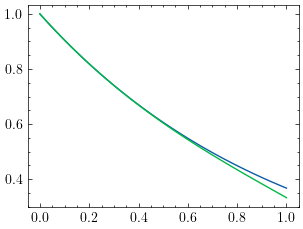

In [95]:
x = np.linspace(0, 1)
y = np.exp(-x)
y_tayl = 1 - x + 1/2 * x** 2 - 1/6 * x**3

plt.plot(x,y)
plt.plot(x, y_tayl)

In [96]:
plt.plot(x, 1/0.1*np.exp(-0.1*y1) - 0.01*x)

ValueError: operands could not be broadcast together with shapes (500,) (50,) 

### K depedendency on PEG contentration

In [6]:
dat = all_data.data
dat = dat[np.sign(dat['charge 1']) == np.sign(dat['charge 2'])]
def filter_quadratic_fits(dat):
    filtering_mask = (dat['chi2_red'] > 0.2) & (dat['chi2_red'] < 10) & (dat['R2'] > 0.5) & (dat['a1_exp'] > 0) & (dat['a2_exp'] < 0)
    return dat[filtering_mask]

dat = filter_quadratic_fits(dat)

In [7]:
df = dat[dat['sample'] == 'ssDNA_13bp']
df.columns

Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'Delta_G_simple_depl_theory_[J/mol]',
       'Delta_G_exp_[J/mol]', 'Delta_G0_exp_[J/mol]'],
      dtype='object')

/tmp/ipykernel_6746/3349392424.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['n Beta conc'] = df['n Beta [1/M]'] * df['concentration [M]']
/tmp/ipykernel_6746/3349392424.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['curve corr'] = -df['a1_exp']/(2 * df['a2_exp'])


(array([16., 22., 10., 14.,  8.,  1.,  8.,  1.,  2.,  1.]),
 array([0.        , 0.22772888, 0.45545776, 0.68318664, 0.91091552,
        1.1386444 , 1.36637328, 1.59410216, 1.82183103, 2.04955991,
        2.27728879]),
 <BarContainer object of 10 artists>)

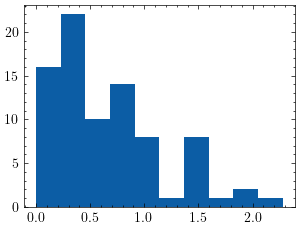

In [29]:
df['n Beta conc'] = df['n Beta [1/M]'] * df['concentration [M]']
df['curve corr'] = -df['a1_exp']/(2 * df['a2_exp'])

wrong = df[df['concentration [M]'] > df['curve corr']]

value, _ = uts.get_float_uncertainty(df['n Beta [1/M]'] * df['concentration [M]'])
plt.hist(value)

In [30]:
wrong

,sample,Rg 1 [nm],Rg 2 [nm],charge 1,charge 2,crowder,molar mass [g/mol],crowder wt. [%],T [K],Na conc. [mM],...,n Beta [1/M],theory_a2,theory_a1,Delta_G_elec_theory_[J/mol],Delta_G_depl_theory_[J/mol],Delta_G_simple_depl_theory_[J/mol],Delta_G_exp_[J/mol],Delta_G0_exp_[J/mol],n Beta conc,curve corr
15,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG20000,20000.0,20.0,298.15,35.0,...,69.8+/-1.6,(-1.17+/-0.05)e+04,985+/-11,(3.885+/-0.015)e+04,-27110.019024,-12783.463843,(-5.71+/-0.06)e+04,(-5.28+/-0.04)e+04,0.720+/-0.016,0.0100+/-0.0027
16,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG20000,20000.0,25.0,298.15,35.0,...,69.8+/-1.6,(-1.17+/-0.05)e+04,985+/-11,(3.728+/-0.016)e+04,-33227.861383,-16114.362970,(-5.67+/-0.04)e+04,(-5.28+/-0.04)e+04,0.908+/-0.020,0.0100+/-0.0027
17,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG20000,20000.0,30.0,298.15,35.0,...,69.8+/-1.6,(-1.17+/-0.05)e+04,985+/-11,(3.593+/-0.016)e+04,-39135.897827,-19499.275363,(-5.63+/-0.06)e+04,(-5.28+/-0.04)e+04,1.099+/-0.025,0.0100+/-0.0027
18,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG20000,20000.0,40.0,298.15,35.0,...,69.8+/-1.6,(-1.17+/-0.05)e+04,985+/-11,(3.369+/-0.017)e+04,-50505.239964,-26431.139947,(-5.30+/-0.04)e+04,(-5.28+/-0.04)e+04,1.490+/-0.034,0.0100+/-0.0027
34,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,15.0,298.15,35.0,...,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(4.085+/-0.013)e+04,-7718.238368,-5225.444378,(-5.42+/-0.07)e+04,(-5.28+/-0.04)e+04,0.520+/-0.012,0.230+/-0.032
35,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,20.0,298.15,35.0,...,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(3.904+/-0.015)e+04,-11209.608481,-7026.637701,(-5.31+/-0.05)e+04,(-5.28+/-0.04)e+04,0.699+/-0.016,0.230+/-0.032
36,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,25.0,298.15,35.0,...,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(3.749+/-0.016)e+04,-15011.267444,-8857.520291,(-5.335+/-0.019)e+04,(-5.28+/-0.04)e+04,0.882+/-0.020,0.230+/-0.032
37,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,30.0,298.15,35.0,...,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(3.614+/-0.016)e+04,-19053.145147,-10718.092146,(-5.225+/-0.025)e+04,(-5.28+/-0.04)e+04,1.067+/-0.024,0.230+/-0.032
38,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,40.0,298.15,35.0,...,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(3.391+/-0.017)e+04,-27652.156014,-14528.303653,(-4.422+/-0.031)e+04,(-5.28+/-0.04)e+04,1.446+/-0.033,0.230+/-0.032
39,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,50.0,298.15,35.0,...,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(3.213+/-0.017)e+04,-36710.380451,-18457.272222,(-3.483+/-0.013)e+04,(-5.28+/-0.04)e+04,1.84+/-0.04,0.230+/-0.032


In [ ]:
wrong = uts.get_float_uncertainty(df['n Beta [1/M]'] * df['concentration [M]'])

In [5]:
dat.columns

Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'Delta_G_simple_depl_theory_[J/mol]',
       'Delta_G_exp_[J/mol]', 'Delta_G0_exp_[J/mol]'],
      dtype='object')

### Theory and experiments

In [6]:
def group_take_first(df, grouping_cols, value_cols):
    return (
        df.groupby(grouping_cols, as_index=False)[value_cols]
          .first()
    )


plot_df = group_take_first(
    dat,
    grouping_cols=['source', 'sample', 'crowder'],
    value_cols=['theory_a1', 'theory_a2', 'a1_exp', 'a2_exp']
)

In [7]:
plot_df

,source,sample,crowder,theory_a1,theory_a2,a1_exp,a2_exp
0,BJ_PEG2000,Catalase-SOD,PEG2000,72.7+/-0.7,-87+/-4,28+/-7,(-9+/-4)e+01
1,IJBCB_PEG2000,XO-SOD1,PEG2000,60.73+/-0.27,-31.3+/-1.4,9+/-5,-19+/-27
2,IJBCB_PEG20000,XO-SOD1,PEG20000,836.3+/-2.7,(-3.18+/-0.14)e+03,130+/-34,(-4.4+/-2.2)e+03
3,JPCB2_PEG8000,10_mer_RNA-RNA,PEG8000,770+/-14,(-1.00+/-0.05)e+04,(1.2+/-0.5)e+02,(-7.0+/-1.6)e+03
4,OriginalData_PEG1000,ssDNA_13bp,PEG1000,39.0+/-0.5,-28.3+/-1.3,15+/-4,-49+/-11
5,OriginalData_PEG12000,ssDNA_13bp,PEG12000,571+/-7,(-4.22+/-0.19)e+03,218+/-28,(-6.4+/-0.8)e+03
6,OriginalData_PEG1500,ssDNA_13bp,PEG1500,60.5+/-0.8,-64.6+/-2.9,26.3+/-3.0,-116+/-9
7,OriginalData_PEG20000,ssDNA_13bp,PEG20000,985+/-11,(-1.17+/-0.05)e+04,(3.1+/-0.6)e+02,(-1.57+/-0.29)e+04
8,OriginalData_PEG3000,ssDNA_13bp,PEG3000,166.9+/-2.5,-617+/-28,51+/-15,(-3.6+/-1.0)e+02
9,OriginalData_PEG35000,ssDNA_13bp,PEG35000,1773+/-19,(-3.60+/-0.16)e+04,(6.8+/-0.8)e+02,(-5.5+/-0.7)e+04


In [8]:
Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'Delta_G_exp_[J/mol]',
       'Delta_G0_exp_[J/mol]']

SyntaxError: incomplete input (2444282435.py, line 9)

In [90]:
df['concentration [M]'].median()

0.026234825

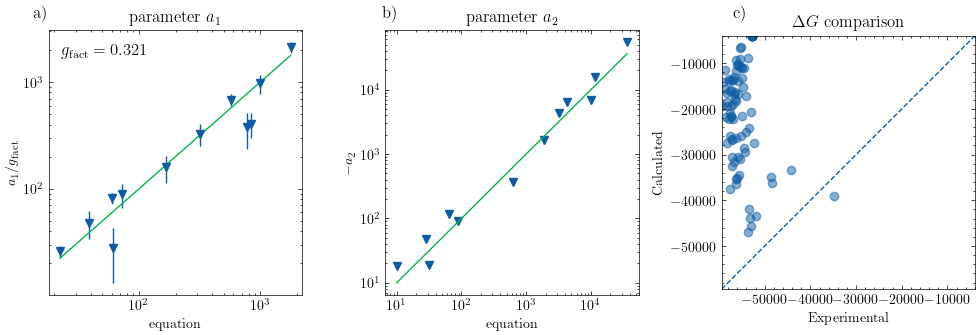

In [57]:
a1_theory, _ = uts.get_float_uncertainty(plot_df['theory_a1'])
a2_theory, _ = uts.get_float_uncertainty(plot_df['theory_a2'])


a1_exp, a1_exp_err = uts.get_float_uncertainty(plot_df['a1_exp'])
a2_exp, a2_exp_err = uts.get_float_uncertainty(plot_df['a2_exp'])

with plt.style.context(['science']):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))

    geom_fact = np.linalg.lstsq(a1_theory[:, np.newaxis], a1_exp, rcond=None)[0][0]
    
    axs[0].errorbar(a1_theory, a1_exp / geom_fact, yerr=a1_exp_err/geom_fact, fmt='v')
    axs[0].set_xlabel('equation')
    axs[0].set_ylabel(r'$a_1/g_{\text{fact}}$')
    axs[0].set_title(r'parameter $a_1$')
    x1 = np.linspace(min(a1_theory), max(a1_theory))
    axs[0].plot(x1, x1)
    axs[0].text(0.05, 0.95, rf'$g_{{\rm fact}} = {geom_fact:.3f}$', 
                transform=axs[0].transAxes, verticalalignment='top', fontsize=12)
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    
    

    axs[1].plot(-a2_theory, -a2_exp, 'v')
    axs[1].set_xlabel('equation')
    axs[1].set_ylabel(r'$-a_2$')
    axs[1].set_title(r'parameter $a_2$')
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    x = np.linspace(min(-a2_theory), max(-a2_theory))
    axs[1].plot(x, x)

    delta_G0, _ = uts.get_float_uncertainty(df['Delta_G0_exp_[J/mol]'])
    delta_G_elec, _ = uts.get_float_uncertainty(df['Delta_G_elec_theory_[J/mol]']) 
    calculated_G =  delta_G_elec + df['Delta_G_simple_depl_theory_[J/mol]'] + delta_G0 
    experimental_G, _ = uts.get_float_uncertainty(df['Delta_G_exp_[J/mol]'])
    #experimental_G -= delta_G0
    
    axs[2].scatter(
        experimental_G,
        calculated_G,
        alpha=0.5
    )
    
    lims = [
        min(experimental_G.min(), calculated_G.min()),
        max(experimental_G.max(), calculated_G.max())
    ]
    
    axs[2].plot(lims, lims, '--') 
    axs[2].set_xlim(lims)
    axs[2].set_ylim(lims)
    
    axs[2].set_xlabel('Experimental')
    axs[2].set_ylabel('Calculated')
    axs[2].set_aspect('equal', adjustable='box')
    axs[2].set_title(r'$\Delta G$ comparison')
    

    fig.text(0.05, 0.95, 'a)', fontsize=12, fontweight='bold', ha='center', va='center')
    fig.text(0.40, 0.95, 'b)', fontsize=12, fontweight='bold', ha='center', va='center')
    fig.text(0.75, 0.95, 'c)', fontsize=12, fontweight='bold', ha='center', va='center')

    
    plt.tight_layout()

In [11]:
df.columns # 'Delta_G_simple_depl_theory_[J/mol]' 'Delta_G_depl_theory_[J/mol]'

Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'Delta_G_simple_depl_theory_[J/mol]',
       'Delta_G_exp_[J/mol]', 'Delta_G0_exp_[J/mol]'],
      dtype='object')

In [42]:
df['crowder'].unique()

array(['PEG600', 'PEG1000', 'PEG1500', 'PEG3000', 'PEG6000', 'PEG12000',
       'PEG20000', 'PEG35000'], dtype=object)

In [41]:
df

,sample,Rg 1 [nm],Rg 2 [nm],charge 1,charge 2,crowder,molar mass [g/mol],crowder wt. [%],T [K],Na conc. [mM],...,chi2_red,R2,n Beta [1/M],theory_a2,theory_a1,Delta_G_elec_theory_[J/mol],Delta_G_depl_theory_[J/mol],Delta_G_simple_depl_theory_[J/mol],Delta_G_exp_[J/mol],Delta_G0_exp_[J/mol]
28,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,0.0,298.15,35.0,...,4.776081,0.980002,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,48804.53891724521+/-0,0.000000,-0.000000,(-5.28+/-0.04)e+04,(-5.28+/-0.04)e+04
29,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,2.5,298.15,35.0,...,4.776081,0.980002,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(4.710+/-0.004)e+04,-931.158933,-852.351605,(-5.53+/-0.05)e+04,(-5.28+/-0.04)e+04
30,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,5.0,298.15,35.0,...,4.776081,0.980002,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(4.559+/-0.006)e+04,-2019.132892,-1712.125527,(-5.37+/-0.06)e+04,(-5.28+/-0.04)e+04
31,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,7.5,298.15,35.0,...,4.776081,0.980002,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(4.423+/-0.009)e+04,-3253.444101,-2579.321765,(-5.46+/-0.04)e+04,(-5.28+/-0.04)e+04
32,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG600,600.0,10.0,298.15,35.0,...,4.776081,0.980002,2.03+/-0.05,-10.0+/-0.4,22.39+/-0.32,(4.300+/-0.010)e+04,-4622.810278,-3453.940319,(-5.49+/-0.04)e+04,(-5.28+/-0.04)e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.0,15.0,298.15,35.0,...,1.619933,0.877961,122.2+/-2.8,(-3.60+/-0.16)e+04,1773+/-19,(4.068+/-0.013)e+04,-21888.909905,-10034.262360,(-5.78+/-0.08)e+04,(-5.28+/-0.04)e+04
260,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.0,20.0,298.15,35.0,...,1.619933,0.877961,122.2+/-2.8,(-3.60+/-0.16)e+04,1773+/-19,(3.884+/-0.015)e+04,-28319.000787,-13493.039272,(-5.83+/-0.10)e+04,(-5.28+/-0.04)e+04
261,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.0,25.0,298.15,35.0,...,1.619933,0.877961,122.2+/-2.8,(-3.60+/-0.16)e+04,1773+/-19,(3.728+/-0.016)e+04,-34445.668682,-17008.827581,(-5.72+/-0.06)e+04,(-5.28+/-0.04)e+04
262,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.0,30.0,298.15,35.0,...,1.619933,0.877961,122.2+/-2.8,(-3.60+/-0.16)e+04,1773+/-19,(3.592+/-0.016)e+04,-40351.997489,-20581.627286,(-5.75+/-0.06)e+04,(-5.28+/-0.04)e+04


/tmp/ipykernel_114284/2803795452.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['molar mass [g/mol]', 'crowder wt. [%]'], inplace=True)


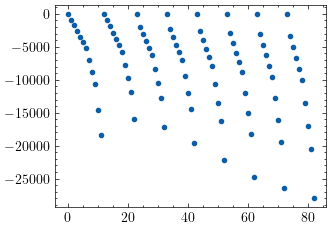

In [70]:
df.sort_values(by=['molar mass [g/mol]', 'crowder wt. [%]'], inplace=True)
simple = df['Delta_G_simple_depl_theory_[J/mol]']
full = df['Delta_G_depl_theory_[J/mol]']

plt.plot(np.arange(len(simple)), simple, '.')

-8408.476572797244

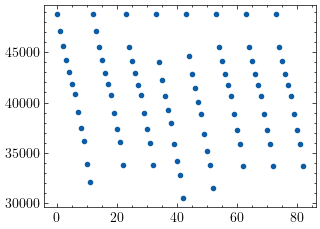

In [45]:
elec, _ = uts.get_float_uncertainty(df['Delta_G_elec_theory_[J/mol]'])
plt.plot(np.arange(len(elec)), elec, '.')

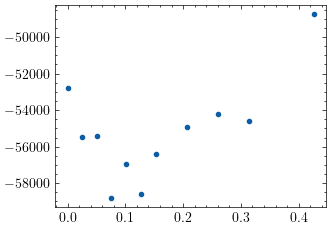

In [86]:
exp, _ = uts.get_float_uncertainty(df['Delta_G_exp_[J/mol]'])
K = 
plt.plot(df['concentration [M]'][13:24], exp[13:24], '.')

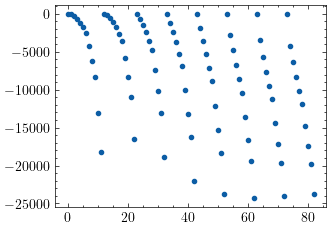

In [65]:
plt.plot(np.arange(len(elec)), full - simple, '.')

In [10]:
plt.plot(np.arange(len(elec)), elec + simple, '.')

0.32063015235383535

In [13]:
a1_exp/a1_theory

array([0.3902026 , 0.14659158, 0.15511707, 0.1568031 , 0.20704656,
       0.28714474, 0.31684832, 0.15374728, 0.1299121 , 0.28400755,
       0.36786515, 0.16675059])

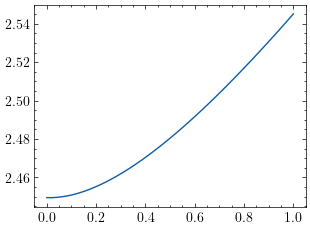

In [82]:
x = np.linspace(0,1)

y = np.sqrt(1/(x + 1) + 5)

plt.plot(x, y + 0.2*x)

In [14]:
print(np.min(-a2_theory), np.max(-a2_theory))

-525.0785362876807 35975.51191836244


In [12]:
print(len(a2_theory), len(a2_exp))

16 16


Estimating values from the PNAS paper

In [2]:
x

In [26]:
def plot_fit(probe):

    x = np.array(PNAS.get_probe(probe)['c [M]'], dtype=np.float64)
    #y, y_error = PNAS.get_float_uncertainty(unp.log(PNAS.get_probe(probe)['K [M]']))

    y, y_error = PNAS.get_float_uncertainty(1/PNAS.get_probe(probe)['K [M]'])

    

    with plt.style.context(['science']):

        plt.plot(x,y, '.')
    

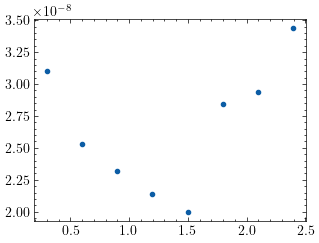

In [27]:
plot_fit('Triethylene glycol')

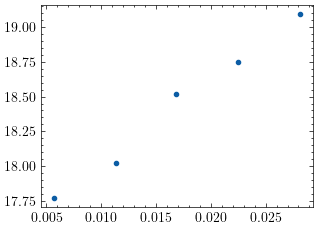

In [23]:
plot_fit('PEG 6000')

In [22]:
coeff = PNAS.coeff

In [23]:
coeff

,peg,a2,a1,a0
0,Ethylene glycol,-0.057416,0.443440,17.264778
1,Diethylene glycol,-0.117488,0.363916,17.358638
2,Triethylene glycol,-0.416552,1.061869,16.993958
3,PEG 200,-0.300799,0.886230,17.157242
4,PEG 400,-1.350031,2.197216,16.886796
5,PEG 1000,-5.402465,5.746480,17.447266
6,PEG 2050,33.233734,4.120859,17.456445
7,PEG 4600,180.611086,38.490130,17.494823
8,PEG 6000,-504.982523,77.456502,17.301372
9,PEG 35000,167454.830381,-306.272949,17.976320


In [2]:
import utils as uts
import sodium_crowder_equilibrium_constant as scec



data =  scec.calc_sodium_crowder_eq_constant()

df_ficoll = data[data['crowder'].str.contains('Ficoll', case=False)]
df_peg = data[data['crowder'].str.contains('PEG', case=False)]
df_dextran = data[data['crowder'].str.contains('Dextran', case=False)]



1425.622636


In [3]:
def choose_crowder(name):
    dat = data[data['crowder'] == name]

    return dat

In [36]:
eg = choose_crowder('PEG200')

In [37]:
eg

,wt_%,D_Na_[um2/s],D_crowder_[um2/s],crowder,MW_[g/mol],No_mono,d_coef,Rg_[nm],Rg_err_[nm],Rh_[nm],Rh_err_[nm],V_Rg_[nm3],V_Rg_err_[nm3],c*_[g/cm3],density,monomers concentration [M],mass concentration [g/cm3],ksi,D_Na_[um2/s] corr
65,1.0,(1.41+/-0.04)e+03,586.6+/-2.6,PEG200,200.0,4.131,0.0012,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,0.9982,0.206178,0.009982,12.093611,1324.065529
66,2.5,1284+/-35,563.1+/-2.0,PEG200,200.0,4.131,0.0012,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.0000,0.516375,0.025000,6.074551,1264.831713
67,5.0,(1.26+/-0.04)e+03,526.8+/-2.2,PEG200,200.0,4.131,0.0012,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.0030,1.035848,0.050150,3.603844,1199.783434
68,7.5,(1.19+/-0.05)e+03,494.6+/-1.8,PEG200,200.0,4.131,0.0012,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.0060,1.558420,0.075450,2.652924,1151.301446
69,10.0,(1.14+/-0.06)e+03,462.2+/-2.1,PEG200,200.0,4.131,0.0012,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.0090,2.084090,0.100900,2.133294,1111.444990
70,12.5,(1.06+/-0.05)e+03,427.2+/-2.4,PEG200,200.0,4.131,0.0012,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.0120,2.612858,0.126500,1.800534,1077.111637
71,15.0,948+/-24,409.2+/-2.8,PEG200,200.0,4.131,0.0012,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.0150,3.144724,0.152250,1.566936,1046.702442
72,17.5,906+/-35,373.3+/-1.7,PEG200,200.0,4.131,0.0012,0.471997,0.025338,0.298714,0.015208,0.440459,0.070935,0.754004,1.0180,3.679688,0.178150,1.392771,1019.264613


In [38]:
def microviscosity(df):
    a, b = 0.7, 1.45
    return np.exp(b * (0.17 / df['ksi']) ** a)
    

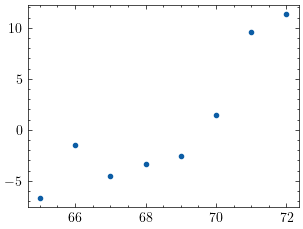

In [39]:
plt.plot((1425 - microviscosity(eg)*uts.get_float_uncertainty(eg['D_Na_[um2/s]'])[0])/1425 * 100, '.')

(array([3., 0., 0., 1., 1., 2., 0., 0., 0., 1.]),
 array([2.54370011, 2.84286076, 3.14202141, 3.44118207, 3.74034272,
        4.03950337, 4.33866402, 4.63782467, 4.93698532, 5.23614598,
        5.53530663]),
 <BarContainer object of 10 artists>)

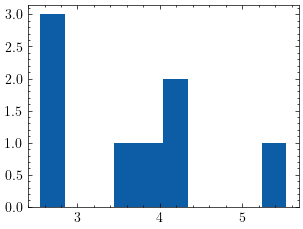

In [40]:
plt.hist(uts.get_float_uncertainty(eg['D_Na_[um2/s]'])[1]/uts.get_float_uncertainty(eg['D_Na_[um2/s]'])[0]*100)

(array([7., 0., 0., 0., 0., 0., 0., 0., 0., 7.]),
 array([0.17960138, 0.1886313 , 0.19766121, 0.20669113, 0.21572105,
        0.22475096, 0.23378088, 0.2428108 , 0.25184071, 0.26087063,
        0.26990055]),
 <BarContainer object of 10 artists>)

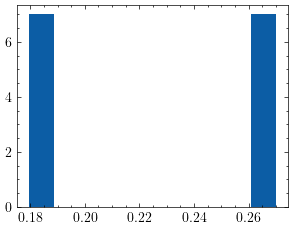

In [3]:
plt.hist(df_dextran['K complex'].apply(lambda x: x.nominal_value))

(array([7., 0., 0., 0., 0., 0., 0., 0., 0., 7.]),
 array([0.54083137, 0.5856832 , 0.63053504, 0.67538688, 0.72023872,
        0.76509056, 0.8099424 , 0.85479424, 0.89964607, 0.94449791,
        0.98934975]),
 <BarContainer object of 10 artists>)

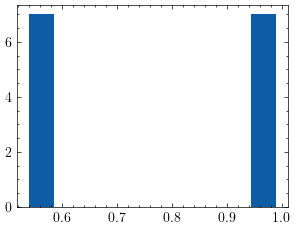

In [4]:
plt.hist(df_dextran['slope'].apply(lambda x: x.nominal_value))

(array([30.,  0.,  0.,  6.,  0.,  7.,  0.,  4.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  4.]),
 array([1.13897208, 1.41478626, 1.69060044, 1.96641462, 2.24222881,
        2.51804299, 2.79385717, 3.06967135, 3.34548553, 3.62129971,
        3.89711389, 4.17292807, 4.44874225, 4.72455643, 5.00037061,
        5.27618479, 5.55199898, 5.82781316, 6.10362734, 6.37944152,
        6.6552557 ]),
 <BarContainer object of 20 artists>)

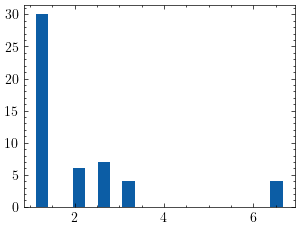

In [5]:
plt.hist(df_peg['slope'].apply(lambda x: x.nominal_value), bins=20)

(array([ 8.,  7.,  0.,  0.,  6.,  0.,  5.,  7.,  6., 12.]),
 array([3.51019292e-05, 5.62261082e-03, 1.12101197e-02, 1.67976286e-02,
        2.23851375e-02, 2.79726464e-02, 3.35601553e-02, 3.91476641e-02,
        4.47351730e-02, 5.03226819e-02, 5.59101908e-02]),
 <BarContainer object of 10 artists>)

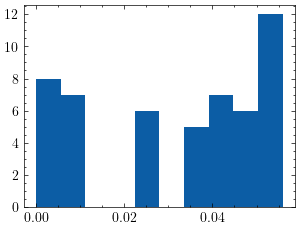

In [6]:
plt.hist(df_peg['K complex'].apply(lambda x: x.nominal_value))

(array([0., 0., 0., 0., 0., 9., 0., 0., 0., 0.]),
 array([-0.13436161, -0.03436161,  0.06563839,  0.16563839,  0.26563839,
         0.36563839,  0.46563839,  0.56563839,  0.66563839,  0.76563839,
         0.86563839]),
 <BarContainer object of 10 artists>)

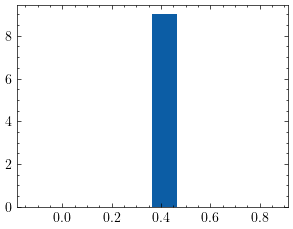

In [7]:
plt.hist(df_ficoll['K complex'].apply(lambda x: x.nominal_value))

(array([0., 0., 0., 0., 0., 9., 0., 0., 0., 0.]),
 array([0.00185126, 0.10185126, 0.20185126, 0.30185126, 0.40185126,
        0.50185126, 0.60185126, 0.70185126, 0.80185126, 0.90185126,
        1.00185126]),
 <BarContainer object of 10 artists>)

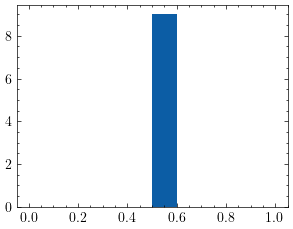

In [8]:
plt.hist(df_ficoll['slope'].apply(lambda x: x.nominal_value))

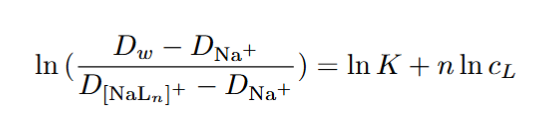

In [12]:
1/0.6

1.6666666666666667

In [31]:
merged_df

,wt_%,D_Na_[um2/s],D_Na_err_[um2/s],D_crowder_[um2/s],D_crowder_err_[um2/s],crowder,MW_[g/mol],No_mono,d_coef,Rg_[nm],Rg_err_[nm],Rh_[nm],Rh_err_[nm],V_Rg_[nm3],V_Rg_err_[nm3],c*_[g/cm3]
0,0.0,1425.622636,30.40000,NaN,Nan,Dextran6000,6000.0,37.005,0.00040,1.750000,0.250000,1.150000,0.150000,22.449298,9.621128,0.443811
1,1.0,1450.000000,88.40000,149.00000,4.39E+00,Dextran6000,6000.0,37.005,0.00040,1.750000,0.250000,1.150000,0.150000,22.449298,9.621128,0.443811
2,1.5,1330.000000,79.90000,142.00000,3.50E+00,Dextran6000,6000.0,37.005,0.00040,1.750000,0.250000,1.150000,0.150000,22.449298,9.621128,0.443811
3,3.0,1300.000000,125.00000,133.00000,2.26E+00,Dextran6000,6000.0,37.005,0.00040,1.750000,0.250000,1.150000,0.150000,22.449298,9.621128,0.443811
4,4.5,1220.000000,113.00000,127.00000,3.12E+00,Dextran6000,6000.0,37.005,0.00040,1.750000,0.250000,1.150000,0.150000,22.449298,9.621128,0.443811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,7.5,1012.123000,72.49846,44.26340,0.616912,PEG6000,6000.0,135.800,0.00155,3.428472,0.028155,2.083015,0.015681,168.807029,4.158841,0.059021
124,10.0,975.738300,121.48850,34.73010,0.192047,PEG6000,6000.0,135.800,0.00155,3.428472,0.028155,2.083015,0.015681,168.807029,4.158841,0.059021
125,12.5,898.482400,53.42060,27.38628,0.128339,PEG6000,6000.0,135.800,0.00155,3.428472,0.028155,2.083015,0.015681,168.807029,4.158841,0.059021
126,15.0,761.920200,56.79781,23.45039,0.231978,PEG6000,6000.0,135.800,0.00155,3.428472,0.028155,2.083015,0.015681,168.807029,4.158841,0.059021


In [26]:
data

,wt_%,D_Na_[um2/s],D_Na_err_[um2/s],D_crowder_[um2/s],D_crowder_err_[um2/s],crowder
0,0.0,1425.622636,30.40000,NaN,Nan,Dextran6000
1,1.0,1450.000000,88.40000,149.00000,4.39E+00,Dextran6000
2,1.5,1330.000000,79.90000,142.00000,3.50E+00,Dextran6000
3,3.0,1300.000000,125.00000,133.00000,2.26E+00,Dextran6000
4,4.5,1220.000000,113.00000,127.00000,3.12E+00,Dextran6000
...,...,...,...,...,...,...
123,7.5,1012.123000,72.49846,44.26340,0.616912,PEG6000
124,10.0,975.738300,121.48850,34.73010,0.192047,PEG6000
125,12.5,898.482400,53.42060,27.38628,0.128339,PEG6000
126,15.0,761.920200,56.79781,23.45039,0.231978,PEG6000


In [20]:
data.columns

Index(['wt_%', 'D_Na_[um2/s]', 'D_Na_err_[um2/s]', 'D_crowder_[um2/s]',
       'D_crowder_err_[um2/s]', 'crowder'],
      dtype='object')

In [24]:
Na0 = data[data['wt_%'] == 0]['D_Na_[um2/s]'].mean()

In [25]:
Na0

1425.622636

(array([ 9., 16.,  7., 12.,  4.,  1.,  0.,  5.,  6.,  2.,  0.,  3.,  8.,
         0.,  1.,  3.,  7.,  3.,  0.,  1.,  6.,  4.,  0.,  1.,  2.,  5.,
         0.,  1.,  1.,  6.]),
 array([0.02913673, 0.16369777, 0.29825881, 0.43281985, 0.56738088,
        0.70194192, 0.83650296, 0.971064  , 1.10562503, 1.24018607,
        1.37474711, 1.50930815, 1.64386919, 1.77843022, 1.91299126,
        2.0475523 , 2.18211334, 2.31667437, 2.45123541, 2.58579645,
        2.72035749, 2.85491852, 2.98947956, 3.1240406 , 3.25860164,
        3.39316268, 3.52772371, 3.66228475, 3.79684579, 3.93140683,
        4.06596786]),
 <BarContainer object of 30 artists>)

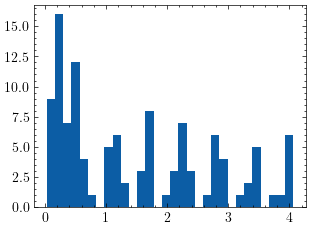

In [3]:
plt.hist(data['monomers concentration [M]'], bins=30)

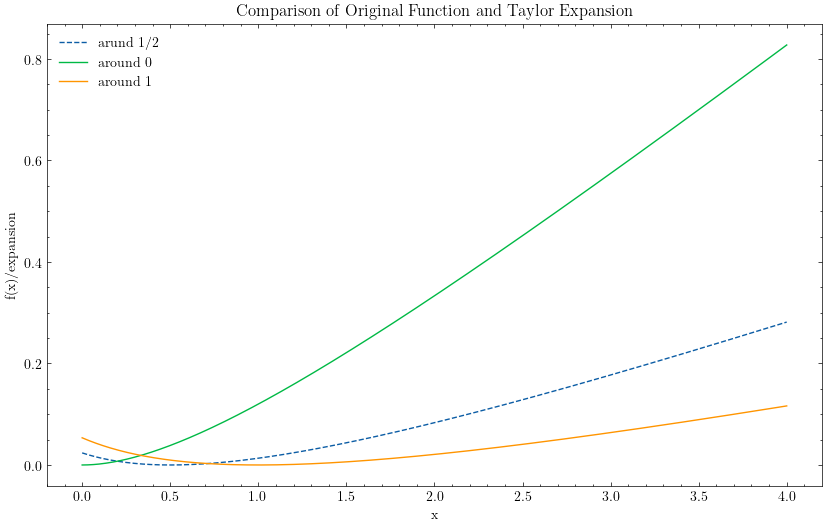

In [4]:
# Constants
A = 1400  # Example value for A
B = 1100  # Example value for B

# Original function
def original_function(x):
    return (A + B * x)/ (1 + x)



def taylor_series_half(x):
      # Centered around x = 1/2
    constant = (1/3) * (2 * A + B)
    linear = -(4/9) * (x - 0.5) * (A - B)
    # Include the first two terms; higher-order terms are denoted by O(h^2)
    return constant + linear


def taylor_series_zero(x):
        
    # Expanded around 0
    return A + (B - A) * x

def taylor_series_one(x):
    #Expanded around 1
    return 1/2 * (A + B) + 1/4 * (x - 1) * (B - A)    
    


# Generate x values for the plot
x = np.linspace(0, 4, 500)

# Evaluate functions
y_original = original_function(x)
y_taylor_half = taylor_series_half(x)
y_taylor_0 = taylor_series_zero(x)
y_taylor_one = taylor_series_one(x)

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(x, (y_original - y_taylor_half)/y_original, '--', label="arund 1/2")
plt.plot(x, (y_original - y_taylor_0)/y_original, label="around  0")
plt.plot(x, (y_original - y_taylor_one)/y_original, label="around  1")

plt.xlabel("x")
plt.ylabel("f(x)/expansion")
plt.title("Comparison of Original Function and Taylor Expansion")
plt.legend()